# 3.2  Generar corpus IL SALUD PERIODO

Los textos de proyectos presentan en promedio 1330 palabras, min 0 palabras max 2078 palabras.


In [1]:
# Importar librerias

from dotenv import load_dotenv
import os
import pandas as pd
import numpy as np
import pickle
import sweetviz as sv
import sys

# Visualización
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
from matplotlib import colormaps

from collections import Counter
from itertools import islice

from tqdm import tqdm
tqdm.pandas()

In [2]:
# Configurar path
load_dotenv() # Cargar las variables de entorno del archivo .env
BASE_DIR =  os.getenv("DIR_BASE")
RESULTADOS_DIR = os.getenv("DIR_DATOS_PROCESADOS") + 'muerte_subita/'# Acceder a las variables de entorno
sys.path.append(BASE_DIR)
sys.path.append(RESULTADOS_DIR)

pd.set_option('display.max_colwidth', None)

In [3]:
# Abrir
with open(RESULTADOS_DIR + 'base_texto_df_ley_0924.pkl', 'rb') as file: 
    df = pickle.load(file)
df.head()

Proyecto.ID  \
1  HCDN255602   
2  HCDN243571   
3  HCDN238109   
4  HCDN215087   
5  HCDN185534   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Cant_token,8.0,1496.500,338.549005,1184.0,1202.00,1433.5,1720.25,2078.0
Cant_token_normalizado,8.0,682.250,158.648533,532.0,541.75,667.5,787.00,938.0
Proyecto_girado_a_comisiones_SALUD,8.0,1.000,0.000000,1.0,1.00,1.0,1.00,1.0
Proyecto_SALUD,8.0,1.000,0.000000,1.0,1.00,1.0,1.00,1.0
Max_Orden,8.0,3.000,0.925820,2.0,2.00,3.0,4.00,4.0
Periodo,8.0,134.375,4.470139,127.0,131.50,135.0,138.00,140.0
Año,8.0,2016.375,4.470139,2009.0,2013.50,2017.0,2020.00,2022.0


In [5]:
# Seleccionando IL de Salud
df = df[df['Proyecto_SALUD']==1]
print("Conj. de datos de proyecto_SALUD con Nan en Período:",df.shape)
df = df[~df['Periodo'].isna()]
print("Conj. de datos de proyecto_SALUD sin Nan en Período:",df.shape)

Conj. de datos de proyecto_SALUD con Nan en Período: (8, 14)
Conj. de datos de proyecto_SALUD sin Nan en Período: (8, 14)


In [6]:
df = df[~(df['texto_proyecto normalizado']==" ")]
print("Conj. de datos de proyecto_SALUD sin texto_proyecto vacio:",df.shape)

Conj. de datos de proyecto_SALUD sin texto_proyecto vacio: (8, 14)


#### N-gramas

In [10]:
from sklearn.feature_extraction.text import CountVectorizer

# Crear bigramas y trigramas
vectorizer = CountVectorizer(ngram_range=(2,5), min_df=1) # Para n-gramas raros , si consideramos min_df = 1, p90=4
X = vectorizer.fit_transform(df['texto_proyecto normalizado'])
n_gramas = vectorizer.get_feature_names_out()
frecuencias = X.sum(axis=0).A1
df_ngrams = pd.DataFrame({'ngram': n_gramas, 'frecuencia': frecuencias})
df_ngrams = df_ngrams.sort_values(by='frecuencia', ascending=False)

In [11]:
df_ngrams.describe() # Se observa n-gramas de n entre 2 a 5 con mínima frecuencia 1


,frecuencia
count,12142.000000
mean,1.791468
std,1.189762
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,20.000000


                                          ngram  frecuencia
8125                           nino adolescente          20
142                            actividad fisico          18
5459                              examen fisico          16
3936                   desfibrilador automatico          15
32                               acceso publico          14
8629                              paro cardiaco          12
9758                        programa prevencion          12
7674                           ministerio salud          12
10097                           publico privado          12
1367                         automatico externo          11
10256                               realizar el          10
9349                               presente ley          10
9208                         practica deportivo          10
9577                             privado acceso           9
2249                              causa natural           9
9578                     privado acceso 

C:\Users\Usuario\AppData\Local\Temp\ipykernel_26196\2334856418.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_ngrams.head(20), x='frecuencia', y='ngram', palette='viridis')


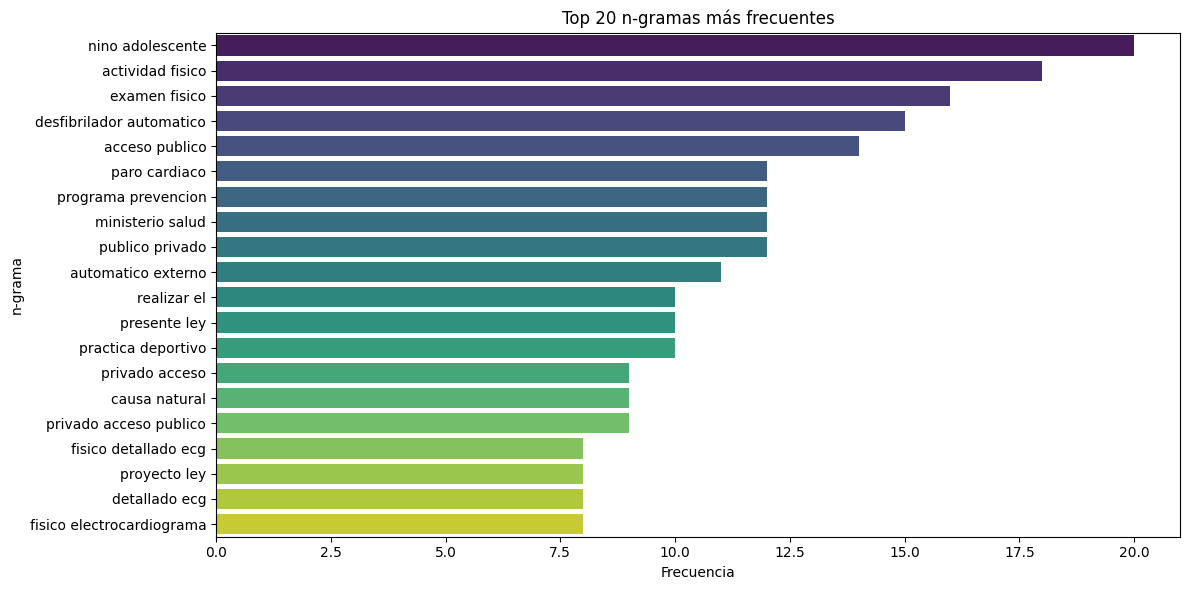

In [12]:
# Mostrar top 50
print(df_ngrams.head(50))

# Visualizar
plt.figure(figsize=(12,6))
sns.barplot(data=df_ngrams.head(20), x='frecuencia', y='ngram', palette='viridis')
plt.title("Top 20 n-gramas más frecuentes")
plt.xlabel("Frecuencia")
plt.ylabel("n-grama")
plt.tight_layout()
plt.show()

,frecuencia
count,1220.000000
mean,4.473770
std,6.461609
min,1.000000
25%,1.000000
50%,2.000000
75%,5.000000
max,77.000000


Text(0.5, 1.0, 'Top 50 palabras más frecuentes')

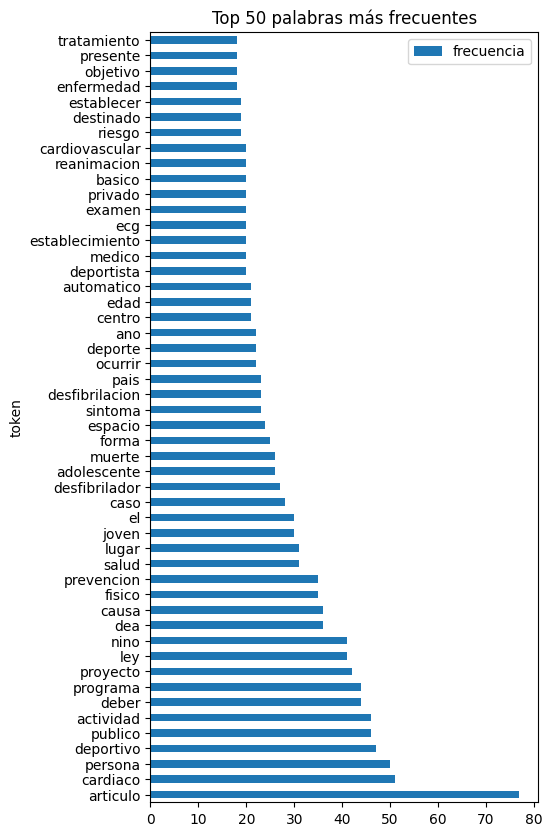

In [13]:
from pprint import pprint
#from gensim import corpora
from collections import defaultdict
from collections import Counter
##################################PASOS DICCIONARIO########################
corpus_norm = list(df['texto_proyecto normalizado'])
# Tokenizamos
documents_tok = [word.split() for word in corpus_norm]

# Creamos el diccionario (vocabulario)
frequency = defaultdict(int)
for doc in documents_tok:
    for token in doc:
        frequency[token] += 1

# Exploramos todas las palabras para limpiar mejor
#counter = Counter(frequency)
frecuencia_df = pd.DataFrame.from_records(list(frequency.items()), columns = ['token','frecuencia'])
display(frecuencia_df.describe())

fig, ax = plt.subplots(figsize=(5, 10))
frecuencia_df.sort_values('frecuencia', ascending=False).head(50).plot(kind='barh', x = 'token', ax=ax)
ax.set_title('Top 50 palabras más frecuentes')


In [14]:
frecuencia_df.sort_values('frecuencia', ascending=False).head(50)

,token,frecuencia
19,articulo,77
158,cardiaco,51
236,persona,50
40,deportivo,47
60,publico,46
136,actividad,46
46,deber,44
6,programa,44
0,proyecto,42
1,ley,41


La selección de períodos de cada 5 años se basa a los periodos de presidencia. Es importante tener en cuenta a la hora de comparar el año 2020, dado que fue el año de inicio de pandemía covid 19, en donde se priorizaron proyectos de salud más que en los otros años. Ver notebook de EDA

* Periodo: 10 de diciembre de 2023 al presente
  Presidente Javier Milei
Ministro de Defensa
Dr. Luis Alfonso Petri

* Periodo: 10 de agosto de 2021 al 10 de diciembre de 2023
Presidente Alberto Fernández
Ministro de Defensa
Lic. Jorge Enrique Taiana

* Periodo: 10 de diciembre de 2019 al 10 de Agosto 2021
Presidente Alberto Fernández
Ministro de Defensa
Ing. Agustín Oscar Rossi

* Periodo: 10 de diciembre de 2015 al 10 de diciembre de 2019
Presidente Mauricio Macri
Ministro de Defensa
Ing. Julio César Martínez – 2015-2017
Dr. Oscar Raúl Aguad – 2017 al 2019

* Periodo: 10 de diciembre de 2011 al 10 de diciembre de 2015
Presidenta Cristina Fernández de Kirchner. Re-elección
Ministro de Defensa
Ing. Agustín Oscar Rossi – 2013 - 2015
Arturo Puricelli – 2011 - 2013

* Periodo: 10 de diciembre de 2007 al 10 de diciembre de 2011
Presidenta Cristina Fernández de Kirchner
Ministro de Defensa
Arturo Puricelli – 2010 - 2011
Nilda Garré – 2007 - 2010

## Cargar Corpus para los tres períodos

In [15]:
df['Periodo_5anios'] = 2009
df.loc[(df['Año']>=2014) & (df['Año']<2019), 'Periodo_5anios'] =  2014
df.loc[(df['Año']>=2019), 'Periodo_5anios'] =  2019

In [16]:
df[['Periodo', 'Año','Periodo_5anios']].describe(include='all')

,Periodo,Año,Periodo_5anios
count,8.000000,8.000000,8.000000
mean,134.375000,2016.375000,2014.625000
std,4.470139,4.470139,4.172615
min,127.000000,2009.000000,2009.000000
25%,131.500000,2013.500000,2012.750000
50%,135.000000,2017.000000,2014.000000
75%,138.000000,2020.000000,2019.000000
max,140.000000,2022.000000,2019.000000


In [17]:
df['Periodo_5anios'].value_counts() # frecuencia absoluto

Periodo_5anios
2019    3
2014    3
2009    2
Name: count, dtype: int64

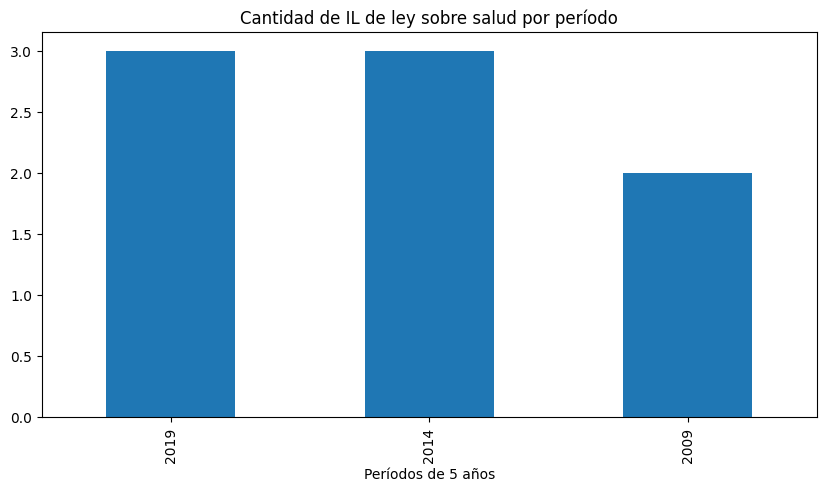

In [18]:
import matplotlib.ticker as ticker
sns.color_palette("pastel")

f, ax = plt.subplots(1, 1, figsize=(10, 5))
df['Periodo_5anios'].value_counts().plot.bar(ax=ax)
ax.set_title('Cantidad de IL de ley sobre salud por período')
ax.set_xlabel("Períodos de 5 años")
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=15))
plt.savefig(BASE_DIR+"imagenes/evolucion_IL_periodo.png")
plt.show()

In [19]:
#concatenando titulos IL
PER5anios_df = df.groupby('Periodo_5anios')['texto_proyecto normalizado'].progress_apply('.'.join).reset_index() 
PER5anios_df['corpus']= PER5anios_df['texto_proyecto normalizado'].progress_apply(lambda x: [sent.split() for sent in x.split('.')])
PER5anios_df['corpus'] = PER5anios_df['corpus'].progress_apply(lambda x: [token.remove(' ') if ' ' in token else token  for token in x ])


100%|████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<?, ?it/s]


In [20]:
print(len(PER5anios_df['corpus'].values[0]))
PER5anios_df['corpus'].values[0]

2


[['proyecto',
  'senado',
  'camara',
  'diputado',
  'ley',
  'prevencion',
  'espacio',
  'acceso',
  'publico',
  'capitulo',
  'disposicion',
  'general',
  'articulo',
  'objeto',
  'objeto',
  'presente',
  'ley',
  'regular',
  'sistema',
  'prevencion',
  'integral',
  'evento',
  'espacio',
  'publico',
  'privado',
  'acceso',
  'publico',
  'articulo',
  'definicion',
  'efecto',
  'ley',
  'considerar',
  'resucitacion',
  'cardiopulmonar',
  'rcp',
  'maniobra',
  'cabo',
  'persona',
  'caso',
  'detencion',
  'circulacion',
  'sangre',
  'destinado',
  'oxigenacion',
  'inmediato',
  'organo',
  'vital',
  'desfibrilacion',
  'maniobra',
  'rcp',
  'incluir',
  'desfibrilador',
  'externo',
  'automatico',
  'dea',
  'desfibrilador',
  'externo',
  'automatico',
  'dea',
  'dispositivo',
  'portatil',
  'utilizado',
  'estimular',
  'electricamente',
  'corazon',
  'persona',
  'paro',
  'cardiaco',
  'espacio',
  'publico',
  'privado',
  'acceso',
  'publico',
  'lugar

In [21]:
# GUARDAR OBJETO PARA DETECTAR CAMBIOS SEMANTICOS
with open(RESULTADOS_DIR + 'periodo_5anios_df.pkl', 'wb') as file: 
    pickle.dump(PER5anios_df,file)

## Analizando frecuencias de palabras por período 
Se tiene en cuenta los períodos parlamentaríos


In [22]:
freqs_list = []
for anios5 in PER5anios_df['Periodo_5anios'].to_list():

    print(anios5)
    subdf = PER5anios_df.loc[(PER5anios_df['Periodo_5anios']==anios5),]
    subdf['texto_proyecto normalizado'] = subdf['texto_proyecto normalizado'].str.replace("."," ")                                 
    
    freqs = Counter()
    subdf['texto_proyecto normalizado'].apply(lambda x: freqs.update(x.split())) # cualquier espacio.
    total_number = sum(freqs.values())
    print('Número total de tokens:', total_number)

    freqs_df = pd.DataFrame.from_dict(freqs, orient='index',
                                      columns=['Frecuencia'])
    freqs_df = freqs_df.reset_index()

    freqs_df = freqs_df.rename(columns={'index': 'Palabra'})
    mask = (freqs_df['Palabra'].str.len() > 1)
    print(freqs_df.shape)
    freqs_df = freqs_df.loc[mask]
    print(freqs_df.shape)
    print('Entradas removidas de 1 carácter.')
    print('Cantidad de tokens únicos:', freqs_df.shape[0])

    freqs_df = freqs_df.sort_values('Frecuencia').reset_index(drop=True)

    freqs_df['Porcentaje'] = freqs_df['Frecuencia'] / total_number

    
    freqs_df.to_csv(RESULTADOS_DIR+'/archivos_out/frec_para_datos_limpios_por_desplaz_semantico_anios5_'+str(anios5)+'.csv', index=False)

    freqs_df['Período'] = str(anios5)
    
    freqs_list.append(freqs_df)
    

2009
Número total de tokens: 1715
(801, 2)
(801, 2)
Entradas removidas de 1 carácter.
Cantidad de tokens únicos: 801
2014
Número total de tokens: 1850
(686, 2)
(686, 2)
Entradas removidas de 1 carácter.
Cantidad de tokens únicos: 686
2019
Número total de tokens: 1893
(694, 2)
(694, 2)
Entradas removidas de 1 carácter.
Cantidad de tokens únicos: 694


C:\Users\Usuario\AppData\Local\Temp\ipykernel_26196\3279904207.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subdf['texto_proyecto normalizado'] = subdf['texto_proyecto normalizado'].str.replace("."," ")
C:\Users\Usuario\AppData\Local\Temp\ipykernel_26196\3279904207.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subdf['texto_proyecto normalizado'] = subdf['texto_proyecto normalizado'].str.replace("."," ")
C:\Users\Usuario\AppData\Local\Temp\ipykernel_26196\3279904207.py:6: SettingWithCopyWarning:

In [23]:
freqs_df = pd.concat(freqs_list) # Dataframe de frecuecias

In [24]:
freqs_df.head(2)

,Palabra,Frecuencia,Porcentaje,Período
0,eventual,1,0.000583,2009
1,crear,1,0.000583,2009


In [25]:
freqs_df = freqs_df.sort_values(by = 'Frecuencia', ascending =False)

##### Top 10 frecuencia de palabra por período de 5 años

In [26]:
freqs_df.head(10).Palabra.unique() # Palabras

array(['articulo', 'persona', 'dea', 'deportivo', 'actividad', 'nino',
       'lugar', 'publico'], dtype=object)

In [27]:
freqs_df.head(10)

,Palabra,Frecuencia,Porcentaje,Período
685,articulo,27,0.014595,2014
800,articulo,26,0.015160,2009
798,persona,26,0.015160,2009
799,dea,26,0.015160,2009
693,deportivo,25,0.013207,2019
692,actividad,25,0.013207,2019
691,articulo,24,0.012678,2019
690,nino,23,0.012150,2019
797,lugar,23,0.013411,2009
796,publico,22,0.012828,2009


##### Las menos 10 frecuencia de palabra por período de 5 años

In [28]:
freqs_df.tail(10).Palabra.unique()

array(['intoxicacion', 'vigente', 'diagnosticado', 'recuperacion',
       'prestar', 'permanezcan', 'estadistica', 'indicar', 'deceso',
       'eventual'], dtype=object)

In [29]:
freqs_df.tail(10)

,Palabra,Frecuencia,Porcentaje,Período
436,intoxicacion,1,0.000583,2009
435,vigente,1,0.000583,2009
434,diagnosticado,1,0.000583,2009
433,recuperacion,1,0.000583,2009
432,prestar,1,0.000583,2009
431,permanezcan,1,0.000583,2009
430,estadistica,1,0.000583,2009
429,indicar,1,0.000583,2009
428,deceso,1,0.000583,2009
0,eventual,1,0.000583,2009


In [30]:
freqs_df.describe(include = 'all') 

,Palabra,Frecuencia,Porcentaje,Período
count,2181,2181.000000,2181.000000,2181
unique,1220,NaN,NaN,3
top,articulo,NaN,NaN,2009
freq,3,NaN,NaN,801
mean,NaN,2.502522,0.001376,NaN
std,NaN,2.895998,0.001592,NaN
min,NaN,1.000000,0.000528,NaN
25%,NaN,1.000000,0.000541,NaN
50%,NaN,2.000000,0.001057,NaN
75%,NaN,3.000000,0.001585,NaN


In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='Frecuencia', ylabel='Count'>

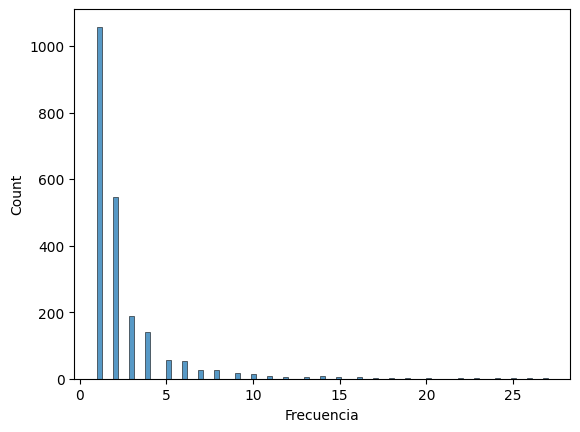

In [32]:
sns.histplot(x = 'Frecuencia', data=freqs_df, bins='auto') # hue='Período'

<Axes: xlabel='Frecuencia'>

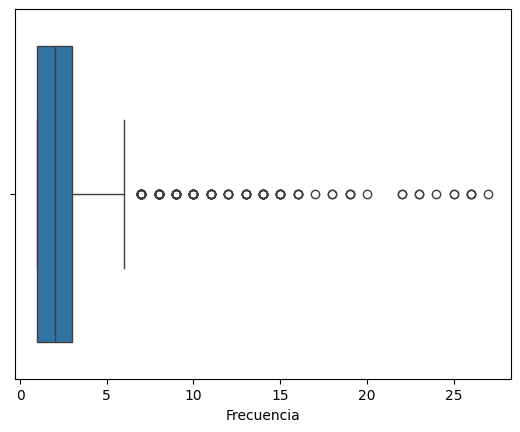

In [33]:
sns.boxplot(x = 'Frecuencia', data=freqs_df)

In [34]:
def eliminar_outliers_iqr(df, columna):
    """
    Separa los outliers y devuelve dos DataFrames:
    - df_limpio: sin outliers
    - df_outliers: con los valores atípicos detectados

    Parámetros:
    df (pd.DataFrame): DataFrame de pandas
    columna (str): Nombre de la columna a analizar

    Retorna:
    df_limpio (pd.DataFrame): DataFrame sin outliers
    df_outliers (pd.DataFrame): DataFrame solo con outliers
    """
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1

    # Definir los límites
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    print("Q1:",Q1)
    print("Q3:",Q3)
    print('limite_inferior:', limite_inferior)
    print('limite_superior:', limite_superior)


    # Filtrar datos
    df_limpio = df[(df[columna] >= limite_inferior) & (df[columna] <= limite_superior)]
    df_outliers = df[(df[columna] < limite_inferior) | (df[columna] > limite_superior)]

    return df_limpio, df_outliers    


In [35]:
# Detectar outliers
freqs_limpio_df , outliers_df = eliminar_outliers_iqr(freqs_df, 'Frecuencia')
display("Outliers detectados:\n", outliers_df)

Q1: 1.0
Q3: 3.0
limite_inferior: -2.0
limite_superior: 6.0


'Outliers detectados:\n'

,Palabra,Frecuencia,Porcentaje,Período
685,articulo,27,0.014595,2014
800,articulo,26,0.015160,2009
798,persona,26,0.015160,2009
799,dea,26,0.015160,2009
693,deportivo,25,0.013207,2019
...,...,...,...,...
631,incluir,7,0.003784,2014
630,problema,7,0.003784,2014
646,presente,7,0.003698,2019
647,forma,7,0.003698,2019


In [36]:
print("Cantidad de palabras por período que superan las 6 veces - OUTLIERS:", len(outliers_df.Palabra.unique()))

Cantidad de palabras por período que superan las 6 veces - OUTLIERS: 78


In [37]:
outliers_df.describe(include='all')

,Palabra,Frecuencia,Porcentaje,Período
count,139,139.000000,139.000000,139
unique,78,NaN,NaN,3
top,articulo,NaN,NaN,2014
freq,3,NaN,NaN,56
mean,NaN,11.374101,0.006229,NaN
std,NaN,5.000396,0.002800,NaN
min,NaN,7.000000,0.003698,NaN
25%,NaN,8.000000,0.004226,NaN
50%,NaN,9.000000,0.005248,NaN
75%,NaN,14.000000,0.007568,NaN


In [38]:
p99 = freqs_df['Frecuencia'].quantile(0.99)
print('Perceptil 99% de Frecuencia:', p99)
display(outliers_df[outliers_df['Frecuencia']> p99].sort_values('Porcentaje', ascending=False))

Perceptil 99% de Frecuencia: 15.199999999999818


,Palabra,Frecuencia,Porcentaje,Período
800,articulo,26,0.015160,2009
798,persona,26,0.015160,2009
799,dea,26,0.015160,2009
685,articulo,27,0.014595,2014
797,lugar,23,0.013411,2009
693,deportivo,25,0.013207,2019
692,actividad,25,0.013207,2019
796,publico,22,0.012828,2009
691,articulo,24,0.012678,2019
690,nino,23,0.012150,2019


<Axes: xlabel='Frecuencia'>

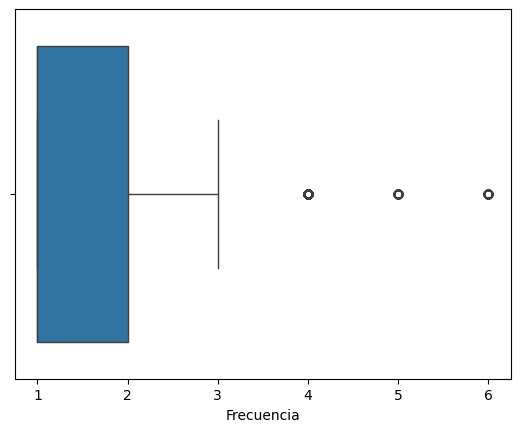

In [39]:
# Miramos distribución sin outliers
sns.boxplot(x = 'Frecuencia', data=freqs_limpio_df)

<Axes: xlabel='Frecuencia', ylabel='Count'>

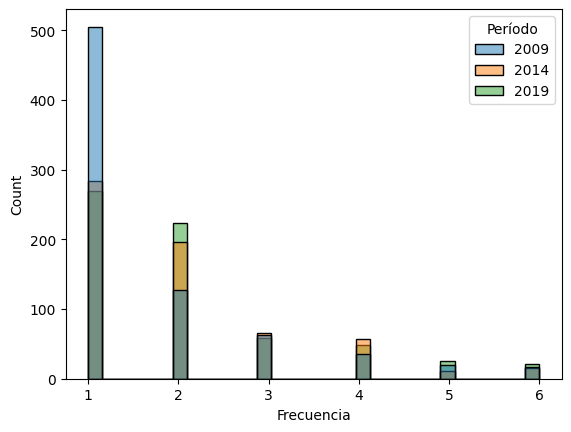

In [40]:
sns.histplot(x = 'Frecuencia', data=freqs_limpio_df,  hue='Período') 

Analizando proyectos de IL de Salud:
* [2009 - 2014) 
    * Número total de tokens: 1715 // 7854
    * Número de tokens únicos: 801 //1713
* [2014 - 2019)
    * Número total de tokens: 1850 // 9740
    * Número de tokens únicos: 686 // 1969
* [2019 - 2024)
    * Número total de tokens: 1893 // 10222
    * Número de tokens únicos: 694 // 1876